In [1]:
import math
import collections
import matplotlib.pyplot as plt

In [2]:
with open("sequence.txt", "r") as file:
    original_sequences = file.read()
    original_sequences = [list(original_sequences.split("\n")[i][15:]) for i in range(0, 64, 8)]

In [3]:
def float_bin(point, size_cod):
    binary_code = ""
    for x in range(size_cod):
        point = point * 2
        if point > 1:
            binary_code = binary_code + str(1)
            x = int(point)
            point = point - x
        elif point < 1:
            binary_code = binary_code + str(0)
        elif point == 1:
            binary_code = binary_code + str(1)

    return binary_code

In [4]:
def encode_ac(uniq_chars, probabilitys, alphabet_size, sequence):
    alphabet = list(uniq_chars)
    probability = [probabilitys[symbol] for symbol in alphabet]
    unity = []
    probability_range = 0.0
    for i in range(alphabet_size):
        l = probability_range
        probability_range = probability_range + probability[i]
        u = probability_range
        unity.append([alphabet[i], l, u])

    for i in range(len(sequence) - 1):
        for j in range(len(unity)):
            if sequence[i] == unity[j][0]:
                probability_low = unity[j][1]
                probability_high = unity[j][2]
                diff = probability_high - probability_low
                for k in range(len(unity)):
                    unity[k][1] = probability_low
                    unity[k][2] = probability[k] * diff + probability_low
                    probability_low = unity[k][2]
                break
    
    low = 0
    high = 0
    for i in range(len(unity)):
        if unity[i][0] == sequence[-1]:
            low = unity[i][1]
            high = unity[i][2]

    point = (low + high) / 2
    size_cod = math.ceil(math.log((1 / (high - low)), 2) + 1)
    bin_code = float_bin(point, size_cod)

    return [point, alphabet_size, alphabet, probability], bin_code

In [5]:
def decode_ac(encoded_data_ac, sequence_length):
    point = encoded_data_ac [0]
    alphabet_size = encoded_data_ac [1]
    alphabet = encoded_data_ac [2]
    probability = encoded_data_ac [3]

    unity = []
    probability_range = 0.0
    for i in range(alphabet_size):
        l = probability_range
        probability_range = probability_range + probability[i]
        u = probability_range
        unity.append([alphabet[i], l, u])

    decoded_sequence = ""
    for i in range(sequence_length):
        for j in range(len(unity)):
            if point > unity[j][1] and point < unity[j][2]:
                prob_low = unity[j][1]
                prob_high = unity[j][2]
                diff = prob_high - prob_low
                decoded_sequence = decoded_sequence + unity[j][0]
                for k in range(len(unity)):
                    unity[k][1] = prob_low
                    unity[k][2] = probability[k] * diff + prob_low
                    prob_low = unity[k][2]
                break

    return decoded_sequence

In [6]:
def encode_hc(uniq_chars, probabilitys, sequence):
    alphabet = list(uniq_chars)

    if len(alphabet) == 1:
        char = alphabet[0]
        symbol_code = [[char, "0"]]
        encode = "0" * len(sequence)
        with open("results_AC_CH.txt", "a") as file:
            file.write(f" {char}       0\n")
        return [encode, symbol_code], encode

    probability = [probabilitys[symbol] for symbol in alphabet]

    final = []
    for i in range(len(alphabet)):
        final.append([alphabet[i], probability[i]])

    final.sort(key=lambda x: x[1])
    tot = 0
    tree = []
    if 1 in probability and len(set(probability)) == 1:
        symbol_code = []
        for i in range(len(alphabet)):
            code = "1" * i + "0"
            symbol_code.append([alphabet[i], code])
            with open("results_AC_CH.txt", "a") as file:
                file.write(f" {alphabet[i]}       {code}\n")
        encode = "".join([symbol_code[alphabet.index(c)][1] for c in sequence])
    else:
        for i in range(len(final) - 1):
            i = 0
            left = final[i]
            final.pop(i)
            right = final[i]
            final.pop(i)
            tot = left[1] + right[1]
            tree.append([left[0], right[0]])
            final.append([left[0] + right[0], tot])
            final.sort(key=lambda x: x[1])
    
    symbol_code = []
    tree.reverse()

    alphabet.sort()
    for i in range(len(alphabet)):
        code = ""
        for j in range(len(tree)):
            if alphabet[i] in tree[j][0]:
                code = code + '0'
                if alphabet[i] == tree[j][0]:
                    break
            else:
                code = code + '1'
                if alphabet[i] == tree[j][1]:
                    break
        symbol_code.append([alphabet[i], code])
        with open("results_AC_CH.txt", "a") as file:
            file.write(f" {alphabet[i]}       {code}\n")

    encode = ""
    for c in sequence:
        encode += [symbol_code[i][1] for i in range(len(alphabet)) if symbol_code[i][0] == c][0]

    return [encode, symbol_code], encode

In [7]:
def decode_hc(encoded_sequence):
    encode = list(encoded_sequence[0])
    symbol_code = encoded_sequence[1]
    count = 0
    flag = 0
    sequence = ""

    for i in range(len(encode)):
        for j in range(len(symbol_code)):
            if encode[i] == symbol_code[j][1]:
                sequence = sequence + str(symbol_code[j][0])
                flag = 1
        if flag == 1:
            flag = 0
        else:
            count = count + 1
            if count == len(encode):
                break
            else:
                encode.insert(i + 1, str(encode[i] + encode[i + 1]))
                encode.pop(i + 2)
        
    return sequence

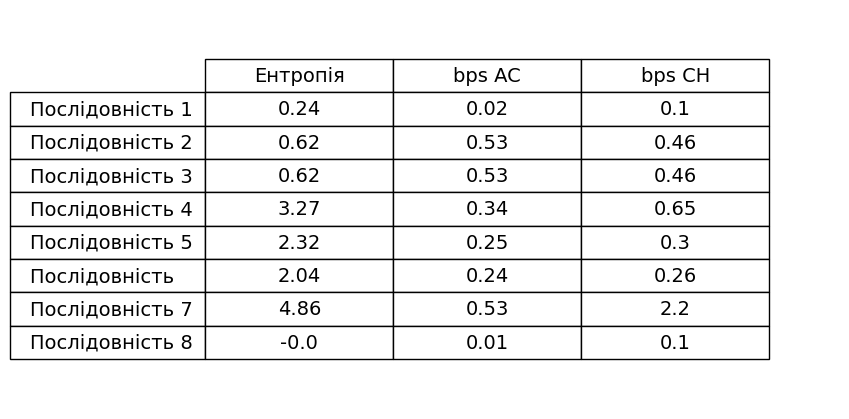

In [8]:
N_sequence = 100
results = []
N = 8

for sequence in original_sequences:
    sequence_length = len(sequence)
    unique_chars = set(sequence)
    sequence_alphabet_size = len(unique_chars)
    counts = collections.Counter(sequence)
    probability = {symbol: count / N_sequence for symbol, count in counts.items()}
    entropy = -sum(p * math.log2(p) for p in probability.values())

    sequence = sequence[:10]

    encoded_data_ac, encoded_sequence_ac = encode_ac(unique_chars, probability, sequence_alphabet_size, sequence)
    bps_ac = len(encoded_sequence_ac) / sequence_length

    decoded_sequence_ac = decode_ac(encoded_data_ac, len(sequence))

    with open("results_AC_CH.txt", "a") as file:
        file.write(f"Послідовність: {''.join(map(str, sequence))}\n"  
                   + f"Ентропія: {entropy}\n"
                   +"_____Арифметичне кодування_____\n"
                   + f"Дані закодованої AC послідовності: {encoded_data_ac}\n"
                   + f"Закодована AC послідовність: {encoded_sequence_ac}\n"
                   + f"Значення bps при кодуванні AC: {bps_ac}\n"
                   + f"Декодована AC послідовність: {decoded_sequence_ac}\n"
                   + "_____Кодування Хаффмана_____\n"
                   + "Алфавіт  Код символу\n"
                   )

    encoded_data_hc, encoded_sequence_hc = encode_hc(unique_chars, probability, sequence)
    bps_hc = len(encoded_sequence_hc) / sequence_length

    decoded_sequence_hc = decode_hc(encoded_data_hc)

    with open("results_AC_CH.txt", "a") as file:
        file.write(f"Дані закодованої НС полідовності: {encoded_data_hc}\n"
                   + f"Закодована НС послідовність: {encoded_sequence_hc}\n"
                   + f"Значення bps при кодуванні НС: {bps_hc}\n"
                   + f"Декодована НС послідовність: {decoded_sequence_hc}\n\n")
    
    results.append([round((entropy), 2), bps_ac, bps_hc])

fig, ax = plt.subplots(figsize=(14/1.54, N/1.54))
headers = ['Ентропія', 'bps AC', 'bps CH']
row = ["Послідовність 1", "Послідовність 2", "Послідовність 3", "Послідовність 4", "Послідовність 5", "Послідовність ", "Послідовність 7", "Послідовність 8"]
ax.axis('off')
table = ax.table(cellText=results, colLabels=headers, rowLabels=row,
loc='center' , cellLoc='center')
table.set_fontsize(14)
table.scale(0.8, 2)
plt.savefig("./Результати стиснення методами AC та CH.png")